IPL 23 Analysis

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

1 

Data Loading

In [40]:
maindf=pd.read_csv("/Users/rudrapratapsinghchouhan/Rudra/projects/ipl/IPL23dataset.csv")

In [41]:
headers=maindf.columns
print(headers)

Index(['Match Number', 'Date', 'Venue', 'Team1', 'Team2', 'Toss winning team',
       'Toss Decision', 'First batting team', 'Second batting team',
       'First Innings Score', 'Overs in First innings', 'Second Innings Score',
       'Overs in Second innings', 'Winning Team', 'Won By'],
      dtype='object')


In [42]:
print(maindf.head().to_string())

   Match Number                     Date                                                                   Venue                Team1                        Team2 Toss winning team Toss Decision First batting team Second batting team First Innings Score  Overs in First innings Second Innings Score  Overs in Second innings                 Winning Team     Won By
0            63   16th May 2023, Tuesday  Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium,  Lucknow       Mumbai Indians         Lucknow Super Giants               MI           bowl                LSG                  MI              177/3                     20.0               172/5                      20.0         Lucknow Super Giants    5 runs.
1            62    15th May 2023, Monday                                       Narendra Modi Stadium,  Ahmedabad       Gujarat Titans          Sunrisers Hyderabad              SRH           bowl                 GT                 SRH              188/9                    

DATA CLEANING & PREPARATION

In [43]:
maindf.shape

(63, 15)

In [44]:
print(maindf['Toss winning team'].value_counts())

Toss winning team
RR       9
CSK      8
MI       7
SRH      7
RCB      7
DC       7
GT       7
PBKS     4
KKR      4
LSG      3
Name: count, dtype: int64


In [45]:
print(maindf['Winning Team'].value_counts())

Winning Team
Gujarat Titans                 9
Lucknow Super Giants           7
Mumbai Indians                 7
Chennai Super Kings            7
Kolkata Knight Riders          6
Royal Challengers Bangalore    6
Punjab Kings                   6
Rajasthan Royals               6
Sunrisers Hyderabad            4
Delhi Capitals                 4
Match Abandoned Due To Rain    1
Name: count, dtype: int64


In [46]:
print((maindf[maindf['Winning Team']=='Match Abandoned Due To Rain']).to_string())

    Match Number                     Date                                                                   Venue         Team1           Team2 Toss winning team Toss Decision First batting team Second batting team First Innings Score  Overs in First innings Second Innings Score  Overs in Second innings                 Winning Team Won By
18            45  3rd May 2023, Wednesday  Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium,  Lucknow  Punjab Kings  Mumbai Indians               MI           bowl                LSG                 CSK             *125/7                     19.2                  NaN                      NaN  Match Abandoned Due To Rain    NaN


Only one row present as case of missing data.

In [ ]:
# Removing rows with missing data.

maindf.drop(18)

DATA TRANSFORMATION.

In [48]:
# Returns a Series where the index is the column name and the value is the dtype
maindf.dtypes


Match Number                 int64
Date                        object
Venue                       object
Team1                       object
Team2                       object
Toss winning team           object
Toss Decision               object
First batting team          object
Second batting team         object
First Innings Score         object
Overs in First innings     float64
Second Innings Score        object
Overs in Second innings    float64
Winning Team                object
Won By                      object
dtype: object

In [49]:
# removing duplicates.

x=maindf.duplicated()
print(list(filter(lambda v:v==1,x)))

#alt

print(x[x==1])




[]
Series([], dtype: bool)


No duplicated values found.

UNIFORM VALUES.

In [ ]:
mapping={
"Mumbai Indians":"MI",
"Rajasthan Royals":"RR",
"Chennai Super Kings":"CSK",
"Gujarat Titans":"GT",
"Delhi Capitals":"DC",
"Kolkata Knight Riders":"KKR",
"Royal Challengers Bangalore":"RCB",
"Punjab Kings":"PBKS",
"Sunrisers Hyderabad":"SRH",
"Lucknow Super Giants":"LSG"
}

maindf=maindf.replace(mapping)

In [ ]:
maindf['Toss winning team']=maindf['Toss winning team'].str.strip()
maindf['Winning Team']=maindf['Winning Team'].str.strip()


In [51]:
# removing superover from "Won by":

maindf[(maindf['Winning Team']==maindf['First batting team']) & (maindf['Won By'].str.contains("wickets", na=False))]
maindf[(maindf['Winning Team']!=maindf['First batting team']) & (maindf['Won By'].str.contains("runs", na=False))]


,Match Number,Date,Venue,Team1,Team2,Toss winning team,Toss Decision,First batting team,Second batting team,First Innings Score,Overs in First innings,Second Innings Score,Overs in Second innings,Winning Team,Won By


Superover data not present in the dataset. 63 of 70 matches present in dataset. 4 playoffs matches data also not present.

ANALYSIS

In [52]:
# creating separate columns match won by runs.

maindf['Wruns']=maindf.loc[maindf['Won By'].str.contains('run', na=False), 'Won By']
maindf['Wwickets']=maindf.loc[maindf['Won By'].str.contains('wicket', na=False), 'Won By']

In [53]:
# extracting numerical data.

maindf['Wruns']=maindf['Wruns'].str.extract(r'(\d+)')
maindf['Wwickets']=maindf['Wwickets'].str.extract(r'(\d+)')

In [54]:
maindf['Wwickets'] = pd.to_numeric(maindf['Wwickets'])
maindf['Wruns'] = pd.to_numeric(maindf['Wruns'])

In [55]:
# extracting numerical data using regex.

# maindf['Wruns']=maindf['Wruns'].str.extract(r"(\d+)").astype('Int64')
# maindf['Wwickets']=maindf['Wwickets'].str.extract(r"(\d+)").astype('Int64')

In [56]:
c1=maindf[maindf['Toss winning team']==maindf['Winning Team']].shape


print(f"Matches in which Match won with toss won or (we can say) match loss with toss loss:{c1[0]}")
print(f"Matches in which Match loss with toss won or (we can say) match won with toss loss:{63-c1[0]}")


Matches in which Match won with toss won or (we can say) match loss with toss loss:0
Matches in which Match loss with toss won or (we can say) match won with toss loss:63


In [57]:
# analysing Matches in which Match won with toss won

c2=len(maindf[(maindf['Toss winning team']==maindf['Winning Team'])&(maindf['Toss Decision']=='bat')])

print(f"Matches in which Match won with toss won:{c1[0]}")
print(f"Matches in which Match won with toss won with toss decision to bat:{c2}")
print(f"Matches in which Match won with toss won with toss decision to ball:{26-c2}")



Matches in which Match won with toss won:0
Matches in which Match won with toss won with toss decision to bat:0
Matches in which Match won with toss won with toss decision to ball:26


In [58]:
# analysing Matches in which Match loss with toss won or (we can say) match won with toss loss.

c3=len(maindf[(maindf['Toss winning team']!=maindf['Winning Team'])&(maindf['Toss Decision']=='bat')])

print(f"Matches in which Match won with toss loss:{63-c1[0]}")
print(f"Matches in which Match won with toss loss with toss decision to bat:{c3}")
print(f"Matches in which Match won with toss loss with toss decision to ball:{37-c3}")



Matches in which Match won with toss loss:63
Matches in which Match won with toss loss with toss decision to bat:19
Matches in which Match won with toss loss with toss decision to ball:18


In [59]:
print(f"games won with toss deceision to bat:{9/26*100}%")
print(f"games won with toss deceision to bowl:{17/26*100}%")

games won with toss deceision to bat:34.61538461538461%
games won with toss deceision to bowl:65.38461538461539%


In [60]:
print(f"games lost with toss deceision to bat:{10/37*100}%")
print(f"games lost with toss deceision to bowl:{27/37*100}%")

games lost with toss deceision to bat:27.027027027027028%
games lost with toss deceision to bowl:72.97297297297297%


Text(0.5, 1.0, 'Toss Desicion to bat')

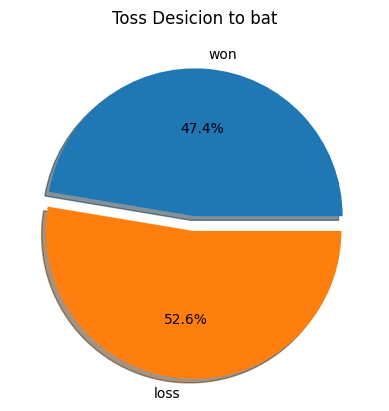

In [61]:
# matches won with ball
categories=['won','loss']

a=np.array([9,10])
a=a.astype(int)
explode=[0,0.1]


plt.pie(a,labels=categories,explode=explode,autopct='%1.1f%%',shadow=True)
plt.title("Toss Desicion to bat")



Text(0.5, 1.0, 'Toss Desicion to bowl')

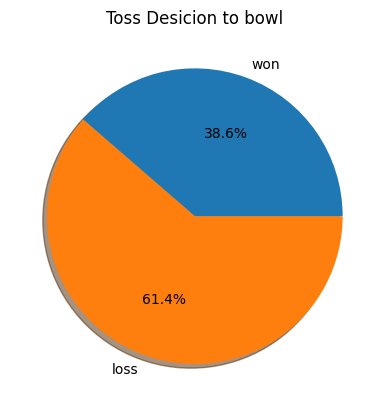

In [62]:
# matches won with bowl
categories=['won','loss']

a=np.array([17,27])


plt.pie(a,labels=categories,autopct='%1.1f%%',shadow=True)
plt.title("Toss Desicion to bowl")



More number of matches were lost because of toss decision to bowl.

analysing toss decision to ball.

In [63]:
maindf.columns

Index(['Match Number', 'Date', 'Venue', 'Team1', 'Team2', 'Toss winning team',
       'Toss Decision', 'First batting team', 'Second batting team',
       'First Innings Score', 'Overs in First innings', 'Second Innings Score',
       'Overs in Second innings', 'Winning Team', 'Won By', 'Wruns',
       'Wwickets'],
      dtype='object')

In [73]:
FISbw=maindf.loc[(maindf['Toss Decision']=='bowl')&
                 (maindf['Toss winning team']==maindf['Winning Team']),
                 'First Innings Score'].str.extract(r'(\d+)/').astype(int)

FISbl=maindf.loc[(maindf['Toss Decision']=='bowl')&
                 (maindf['Toss winning team']!=maindf['Winning Team']),
                 'First Innings Score'].str.extract(r'(\d+)/').astype(int)

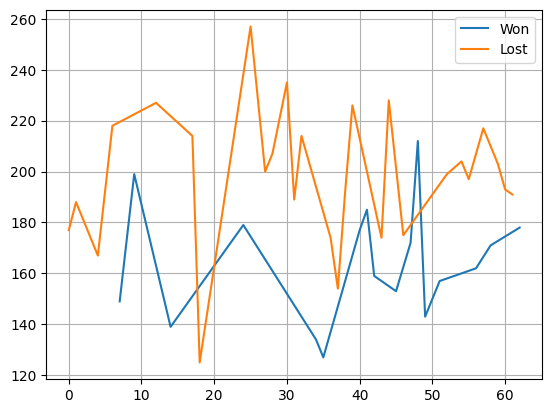

In [75]:
plt.plot(FISbw, label='Won')
plt.plot(FISbl, label='Lost')

plt.grid()
plt.legend()
plt.show()

In [76]:
print(f"Average winning first inning score after electing bowl:{FISbw.mean()}")
print(f"Average lossing first inning score after electing bowl:{FISbl.mean()}")

Average winning first inning score after electing bowl:0    164.470588
dtype: float64
Average lossing first inning score after electing bowl:0    197.962963
dtype: float64


In [ ]:
print(f"median winning first inning score after electing bowl:{FISbw.median()}")
print(f"median lossing first inning score after electing bowl:{FISbl.median()}")

Average winning first inning score after electing bowl:0    162.0
dtype: float64
Average lossing first inning score after electing bowl:0    199.0
dtype: float64


analysing toss decision to ball.

In [79]:
FISbtw=maindf.loc[(maindf['Toss Decision']=='bat')&
                 (maindf['Toss winning team']==maindf['Winning Team']),
                 'First Innings Score'].str.extract(r'(\d+)/').astype(int)

FISbtl=maindf.loc[(maindf['Toss Decision']=='bat')&
                 (maindf['Toss winning team']!=maindf['Winning Team']),
                 'First Innings Score'].str.extract(r'(\d+)/').astype(int)

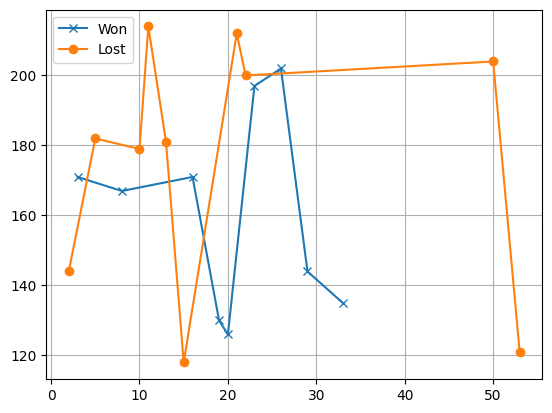

In [81]:
plt.plot(FISbtw, label='Won',marker='x')
plt.plot(FISbtl, label='Lost',marker='o')

plt.grid()
plt.legend()
plt.show()

In [83]:
print(f"Average winning first inning score after electing bat:{FISbtw.mean()}")
print(f"Average lossing first inning score after electing bat:{FISbtl.mean()}")

Average winning first inning score after electing bat:0    160.333333
dtype: float64
Average lossing first inning score after electing bat:0    175.5
dtype: float64


In [84]:
print(len(FISbtl),len(FISbtw))

10 9


Analomous Conclusions.

Toss decision analysed succesfully!!